# Telecom Customer Churn Analysis & Retention Strategy

## Business Analytics Case Study: Statistical Validation, Customer Segmentation, KPI Dashboarding, and Retention Impact Simulation



## Business Context

Customer churn is a major business challenge for telecom companies because it directly reduces recurring revenue, lowers customer lifetime value, and increases customer acquisition costs.

This project analyzes telecom customer behavior to identify key churn drivers, uncover high-risk customer segments, and translate data patterns into actionable retention strategies.

# Business Problem

The telecom industry is highly competitive, and customers can switch providers with minimal friction. High customer churn negatively impacts recurring revenue, customer lifetime value, and overall business profitability.

Understanding the behavioral and service-related factors driving churn is essential for improving customer retention and developing proactive retention strategies.

This analysis focuses on answering the following key business questions:

- Which customers are most likely to churn?
- Which service, pricing, and contract patterns are associated with churn?
- Which customer segments require immediate retention focus?
- What business actions can help reduce customer attrition?

# Project Objective

The objective of this project is to analyze customer churn behavior and identify the key factors influencing customer retention in the telecom industry.

This analysis aims to:

- Understand customer demographics, subscription behavior, and service usage patterns
- Analyze the relationship between contract type, payment behavior, pricing, and churn
- Identify high-risk customer segments with elevated churn probability
- Discover behavioral patterns associated with customer attrition
- Generate data-driven business recommendations to improve customer retention

# Tools and Technologies Used

## Programming & Data Analysis
- Python
- Pandas

## Data Visualization
- Matplotlib
- Seaborn

## Statistical Analysis
- SciPy

## Development Environment
- Google Colab


# Skills Demonstrated

- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Statistical Analysis & Hypothesis Testing
- Customer Segmentation
- Data Visualization & Storytelling
- Churn Pattern Analysis
- Business Insight Generation
- Retention Strategy Development
- Business-Oriented Problem Solving

# Dataset Overview

The analysis was conducted using the Telco Customer Churn dataset, which contains customer-level information related to demographics, subscription services, internet usage, contract structure, payment behavior, pricing, tenure, and churn status.

Each row in the dataset represents an individual customer, while the target variable — `Churn` — indicates whether the customer discontinued the telecom service or remained active.

## Dataset Shape

- Rows: 7,043
- Columns: 21

## Dataset Features

The dataset includes both categorical and numerical variables related to:

- Customer demographics
- Internet service usage
- Contract type
- Payment method
- Monthly charges
- Total charges
- Customer tenure
- Churn status

This combination of variables allows for customer segmentation, churn pattern analysis, statistical validation, and business-focused retention recommendations.

# Importing Libraries

The following libraries are used for data cleaning, analysis, visualization, and statistical exploration throughout the project.

In [297]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

# Loading the Dataset

The dataset is loaded into a Pandas DataFrame for further cleaning, exploration, and churn analysis.

In [298]:
df = pd.read_csv("Telco-Customer-Churn.csv")

# Data Understanding
Before performing exploratory analysis, the dataset was examined to understand its structure, feature types, statistical characteristics, and overall data quality.

## Preview of the Dataset

The initial rows of the dataset were reviewed to understand the available features, customer attributes, and overall dataset structure.

In [299]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Dimensions

The dataset dimensions were examined to understand the total number of customer records and available features for analysis.

In [300]:
df.shape

(7043, 21)

## Dataset Structure and Feature Types

The dataset structure was reviewed to examine column names, data types, and missing value presence across all features.

In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Cleaning

Data cleaning was performed to ensure the dataset was accurate, consistent, and suitable for reliable churn analysis.

## Cleaning Steps Performed

- Identified that `TotalCharges` was incorrectly stored as an object data type instead of a numerical variable
- Converted `TotalCharges` into numeric format using `pd.to_numeric()`
- Checked for missing values generated during conversion
- Removed incomplete records containing missing values
- Verified dataset consistency and structure after cleaning

In [302]:
df['TotalCharges'].dtype

dtype('O')

## Identifying Missing Values in `TotalCharges`

Blank spaces in the `TotalCharges` column were identified before converting the feature into numerical format.

In [303]:
(df['TotalCharges'] == " ").sum()

np.int64(11)

## Converting `TotalCharges` to Numeric Format

The `TotalCharges` feature was converted into numerical format to enable accurate statistical analysis and numerical computations.

In [304]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [305]:
df['TotalCharges'].dtype

dtype('float64')

## Checking Missing Values

Missing values across all dataset features were examined after converting `TotalCharges` into numerical format.

In [306]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Removing Missing Records

Rows containing missing values were removed to maintain dataset consistency and ensure reliable statistical analysis.

In [307]:
df = df.dropna()

## Why Missing Rows Were Removed Instead of Imputed

Only 11 rows out of 7,043 contained missing values after the `TotalCharges` conversion, representing a very small portion of the dataset.

Because the missing proportion was negligible, removing those records was considered the cleanest and most reliable approach. This avoided introducing artificial values through imputation and preserved the integrity of the analysis.

## Checking Duplicate Records

The dataset was checked for duplicate customer records to ensure data consistency and avoid biased analytical results.

In [308]:
df.duplicated().sum()

np.int64(0)

## Verifying Dataset Structure After Cleaning

The dataset structure was re-evaluated after cleaning to confirm successful handling of missing values and datatype corrections.

In [309]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

# Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand customer behavior patterns, numerical feature distributions, categorical relationships, and churn-related trends within the dataset.

The analysis focuses on identifying meaningful business patterns, high-risk customer groups, and variables strongly associated with customer churn.

## Statistical Summary of Numerical Features

Statistical summaries were reviewed to understand the distribution, central tendency, variability, and range of key numerical variables.

In [310]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## Summary of Categorical Features

Categorical feature distributions were reviewed to understand dominant customer categories, service preferences, and subscription behavior patterns.

In [311]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


# Feature-Level Exploratory Analysis


## Univariate Analysis

### Customer Churn Distribution

#### Business Question

What proportion of customers are leaving the telecom service?

#### Why This Matters

Understanding overall churn distribution helps evaluate customer retention performance and the scale of customer attrition within the business.

In [312]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [313]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


#### Key Insight

Approximately 26.5% of customers have churned, indicating a significant customer retention challenge for the telecom business.

The imbalance between retained and churned customers also highlights the importance of identifying high-risk customer segments and proactive retention strategies.

### Contract Distribution Analysis
#### Business Question

What is the distribution of customers across different contract types?

#### Why This Matters

Contract duration reflects customer commitment and retention stability. Customers with shorter contracts are generally more likely to switch providers compared to customers with long-term agreements.


In [314]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1685
One year,1472


In [315]:
df['Contract'].value_counts(normalize=True) * 100

,proportion
Contract,
Month-to-month,55.105233
Two year,23.961889
One year,20.932878


#### Key Insight

More than half of the customers are subscribed to month-to-month contracts, while significantly fewer customers are enrolled in one-year or two-year plans.

This indicates that a large portion of the customer base has low contractual commitment, which may contribute to elevated churn risk.

### Payment Method Distribution Analysis

#### Business Question

Which payment methods are most commonly used by customers?

#### Why This Matters

Payment behavior can reflect customer convenience, automation preference, and billing experience. Certain payment methods may also be associated with higher churn behavior.

In [316]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1604
Bank transfer (automatic),1542
Credit card (automatic),1521


In [317]:
df['PaymentMethod'].value_counts(normalize=True) * 100

,proportion
PaymentMethod,
Electronic check,33.631968
Mailed check,22.810011
Bank transfer (automatic),21.928328
Credit card (automatic),21.629693


#### Key Insight

Electronic check is the most commonly used payment method among customers, accounting for a substantial portion of the customer base.

This observation becomes particularly important later in the analysis, as electronic check customers demonstrate comparatively higher churn behavior.

### Internet Service Distribution Analysis

#### Business Question

Which internet services are most commonly subscribed to by customers?

#### Why This Matters

Internet service type significantly influences customer experience, pricing structure, service quality perception, and churn behavior.

In [318]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2416
No,1520


In [319]:
df['InternetService'].value_counts(normalize=True) * 100

,proportion
InternetService,
Fiber optic,44.027304
DSL,34.357224
No,21.615472


#### Key Insight

Fiber optic service represents a major portion of the customer base, followed by DSL services.

Because internet service quality and pricing strongly affect customer satisfaction, this variable becomes an important factor in later churn analysis.

### Tenure Distribution Analysis

#### Business Question

How long have customers typically stayed with the telecom company?

#### Why This Matters

Customer tenure reflects loyalty and customer retention stability. Customers with shorter tenure are generally more likely to leave because they have weaker long-term attachment to the service.

In [320]:
df['tenure'].describe()

,tenure
count,7032.000000
mean,32.421786
std,24.545260
min,1.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


#### Key Insight

Customers demonstrate wide variation in tenure, indicating the presence of both newly acquired and long-term loyal subscribers.

Additionally, 25% of customers have tenure below 9 months, suggesting a sizable early-stage customer segment that may be more vulnerable to churn.

### Monthly Charges Distribution Analysis

#### Business Question

How are monthly subscription charges distributed across customers?

#### Why This Matters

Monthly pricing directly affects customer affordability, perceived service value, and customer satisfaction. Higher monthly charges may contribute to increased churn risk.

In [321]:
df['MonthlyCharges'].describe()

,MonthlyCharges
count,7032.000000
mean,64.798208
std,30.085974
min,18.250000
25%,35.587500
50%,70.350000
75%,89.862500
max,118.750000


#### Key Insight

Monthly charges demonstrate significant variability across customers, indicating the presence of multiple pricing tiers and service subscription patterns.

The median monthly charge is slightly higher than the mean, suggesting a mild left-skewed distribution where a subset of lower-paying customers pulls the average downward.

Additionally, the wide spread between minimum and maximum charges highlights substantial diversity in customer billing behavior and service adoption.

### Demographic Feature Overview

#### Business Question

What does the customer demographic composition look like?

#### Why This Matters

Demographic variables provide supporting context about the customer base. However, they should be interpreted carefully because demographic balance alone does not necessarily explain churn behavior.

In [322]:
df['gender'].value_counts(normalize=True) * 100

,proportion
gender,
Male,50.469283
Female,49.530717


In [323]:
df['SeniorCitizen'].value_counts(normalize=True) * 100

,proportion
SeniorCitizen,
0,83.759954
1,16.240046


In [324]:
df['Partner'].value_counts(normalize=True) * 100

,proportion
Partner,
No,51.749147
Yes,48.250853


In [325]:
df['Dependents'].value_counts(normalize=True) * 100

,proportion
Dependents,
No,70.150739
Yes,29.849261


#### Key Insight

The customer base is almost evenly distributed by gender, while senior citizens represent a smaller segment at approximately 16.2%.

Partner status is relatively balanced, but most customers do not have dependents, with around 70.2% belonging to the no-dependents category.

Overall, these demographic variables provide useful customer composition context, but stronger churn-related patterns are observed in behavioral and service-related features such as contract type, tenure, payment method, internet service, and monthly charges.

## Bivariate Analysis

After understanding individual customer features, the next step is to analyze how these variables relate to customer churn behavior.

This section focuses on identifying the strongest churn drivers and uncovering high-risk customer segments.

### Contract Type vs Churn Analysis

#### Business Question

How does customer contract type influence churn behavior?

#### Why This Matters

Contract type is one of the strongest indicators of customer commitment and retention stability. Understanding its relationship with churn can help identify high-risk customer groups and improve retention strategies.

In [326]:
df.groupby('Contract')['Churn'].value_counts()


Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1306
                Yes       166
Two year        No       1637
                Yes        48
Name: count, dtype: int64

In [327]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


#### Key Insight

Contract type shows a strong relationship with customer churn behavior. Customers with month-to-month contracts demonstrate significantly higher churn rates compared to customers with one-year and two-year contracts.

This suggests that longer contract commitments are associated with stronger customer retention and greater subscription stability. The elevated churn among month-to-month customers may indicate lower customer commitment and easier provider switching.

### Payment Method vs Churn Analysis

#### Business Question

Does customer payment method influence churn behavior?
#### Why This Matters

Payment behavior can reflect customer commitment, convenience preference, and billing experience. Identifying high-risk payment categories can support targeted retention strategies.

In [328]:
df.groupby('PaymentMethod')['Churn'].value_counts()

PaymentMethod              Churn
Bank transfer (automatic)  No       1284
                           Yes       258
Credit card (automatic)    No       1289
                           Yes       232
Electronic check           No       1294
                           Yes      1071
Mailed check               No       1296
                           Yes       308
Name: count, dtype: int64

In [329]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


#### Key Insight

Electronic check users show the highest churn rate at approximately 45.3%.

Customers using automatic payment methods have much lower churn rates:
- Bank transfer: approximately 16.7%
- Credit card: approximately 15.3%

This suggests that electronic check customers form a high-risk payment segment, while automatic payment users show stronger retention stability.

### Internet Service vs Churn Analysis

#### Business Question

Does internet service type influence customer churn behavior?
#### Why This Matters

Different internet service categories may reflect varying customer expectations, pricing sensitivity, and service experience, all of which can influence churn risk.

In [330]:
df.groupby('InternetService')['Churn'].value_counts()

InternetService  Churn
DSL              No       1957
                 Yes       459
Fiber optic      No       1799
                 Yes      1297
No               No       1407
                 Yes       113
Name: count, dtype: int64

In [331]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


#### Key Insight

Customers using fiber optic internet services exhibit the highest churn rate at approximately 41.9%, compared to DSL users at approximately 19.0% and customers without internet services at approximately 7.4%.

This suggests that fiber optic customers may represent a higher-risk customer segment, potentially influenced by pricing concerns, service expectations, or competitive alternatives.

### Monthly Charges vs Churn Analysis
#### Business Question

Do higher monthly charges influence customer churn behavior?
#### Why This Matters

Pricing is a major factor affecting customer satisfaction and retention. Analyzing churn behavior across monthly charge levels helps identify potential pricing-related churn risks.

In [332]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


#### Key Insight

Customers who churn show substantially higher monthly charges, with an average monthly payment of approximately 74.44 monetary units compared to 61.31 monetary units for retained customers.

Churned customers also maintain consistently higher charge levels across the distribution, suggesting that higher pricing may be strongly associated with increased churn risk and possible pricing sensitivity.

### Tenure vs Churn Analysis
#### Business Question

How does customer tenure relate to churn behavior?
#### Why This Matters

Customer tenure reflects subscription longevity and loyalty. Understanding tenure-based churn patterns helps identify vulnerable early-stage customers and long-term retention trends.

In [333]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


#### Key Insight

Customers who churn exhibit significantly lower tenure levels compared to retained customers.

The average tenure of churned customers is approximately 18 months, whereas retained customers stay for nearly 38 months on average, indicating that long-term customers are substantially more loyal and less likely to discontinue the service.

This suggests that early-stage customers represent a critical high-risk churn segment and may require stronger onboarding, engagement, and retention strategies.

### Senior Citizen vs Churn Analysis
#### Business Question

Does senior citizen status influence customer churn behavior?
#### Why This Matters

Senior citizens may demonstrate different service usage patterns, pricing sensitivity, and support requirements, which can influence customer retention behavior.

In [334]:
df.groupby('SeniorCitizen')['Churn'].value_counts()

SeniorCitizen  Churn
0              No       4497
               Yes      1393
1              No        666
               Yes       476
Name: count, dtype: int64

In [335]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


#### Key Insight

Senior citizens show a higher churn rate (approx 41.7%) compared to non-senior customers (~23.7%), indicating relatively greater churn vulnerability within the senior customer segment.

## Multivariate Analysis

After identifying important churn-related variables individually, multivariate analysis was performed to understand how combinations of customer characteristics influence churn behavior.

This section focuses on identifying more specific high-risk customer profiles by analyzing multiple churn-related factors together.

### Contract Type and Payment Method vs Churn Analysis

#### Business Question

How do contract type and payment method together influence customer churn behavior?

#### Why This Matters

Contract type reflects customer commitment, while payment method reflects billing behavior and payment convenience. Analyzing both together helps identify more specific customer segments with elevated churn risk.

In [336]:
pd.crosstab(
    [df['Contract'], df['PaymentMethod']],
    df['Churn'],
    normalize='index'
) * 100

Churn                                            No        Yes
Contract       PaymentMethod                                  
Month-to-month Bank transfer (automatic)  65.874363  34.125637
               Credit card (automatic)    67.219153  32.780847
               Electronic check           46.270270  53.729730
               Mailed check               68.421053  31.578947
One year       Bank transfer (automatic)  90.281330   9.718670
               Credit card (automatic)    89.698492  10.301508
               Electronic check           81.556196  18.443804
               Mailed check               93.154762   6.845238
Two year       Bank transfer (automatic)  96.619217   3.380783
               Credit card (automatic)    97.758621   2.241379
               Electronic check           92.261905   7.738095
               Mailed check               99.200000   0.800000

#### Key Insight

Month-to-month customers using electronic check show the highest churn rate at approximately 53.7%, making them the riskiest customer segment in this analysis.

Across all payment methods, churn rates are much lower for one-year and two-year contract customers, showing that contract duration has a strong influence on retention.

This suggests that customers with flexible contracts and electronic check payments should be prioritized for targeted retention campaigns.

### Contract Type and Internet Service vs Churn Analysis

#### Business Question

How do contract type and internet service together influence customer churn behavior?

#### Why This Matters

Contract type reflects customer commitment, while internet service type reflects service experience and pricing exposure. Analyzing both together helps identify customer groups with stronger churn vulnerability.

In [337]:
pd.crosstab(
    [df['Contract'], df['InternetService']],
    df['Churn'],
    normalize='index'
) * 100

Churn                                  No        Yes
Contract       InternetService                      
Month-to-month DSL              67.784137  32.215863
               Fiber optic      45.394737  54.605263
               No               81.106870  18.893130
One year       DSL              90.701754   9.298246
               Fiber optic      80.705009  19.294991
               No               97.520661   2.479339
Two year       DSL              98.073836   1.926164
               Fiber optic      92.773893   7.226107
               No               99.210111   0.789889

#### Key Insight

Month-to-month customers using fiber optic internet show the highest churn rate at approximately 54.6%, making them one of the strongest high-risk customer segments.

Churn drops sharply for one-year and two-year contracts across all internet service types, suggesting that longer contract commitments improve retention even among higher-risk fiber optic users.

### Tenure Group and Contract Type vs Churn Analysis

#### Business Question

Which combination of customer tenure and contract type shows the highest churn risk?

#### Why This Matters

Customer tenure reflects lifecycle stage, while contract type reflects commitment level. Combining both helps identify customers who are most vulnerable during early retention stages.

In [338]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 Months', '13-24 Months', '25-48 Months', '49-72 Months'],
    include_lowest=True
)

In [339]:
pd.crosstab(
    [df['TenureGroup'], df['Contract']],
    df['Churn'],
    normalize='index'
) * 100

Churn                                No        Yes
TenureGroup  Contract                             
0-12 Months  Month-to-month   48.645938  51.354062
             One year         89.430894  10.569106
             Two year        100.000000   0.000000
13-24 Months Month-to-month   62.279512  37.720488
             One year         91.878173   8.121827
             Two year        100.000000   0.000000
25-48 Months Month-to-month   67.082294  32.917706
             One year         89.382239  10.617761
             Two year         97.810219   2.189781
49-72 Months Month-to-month   73.976608  26.023392
             One year         87.066246  12.933754
             Two year         96.674584   3.325416

#### Key Insight

New month-to-month customers show the highest churn risk, with churn exceeding 51% in the 0–12 month tenure group.

Churn generally decreases as tenure increases, especially for customers on longer contracts, suggesting that early-stage month-to-month customers should be prioritized for retention.

### Monthly Charges Group and Contract Type vs Churn Analysis

#### Business Question

How does churn vary across monthly pricing levels and contract types?

#### Why This Matters

Monthly charges reflect customer pricing exposure, while contract type reflects commitment level. Analyzing both together helps identify whether high-paying customers on flexible contracts are more vulnerable to churn.

In [340]:
df['MonthlyChargeGroup'] = pd.qcut(
    df['MonthlyCharges'],
    q=3,
    labels=['Low Charges', 'Medium Charges', 'High Charges']
)

In [341]:
pd.crosstab(
    [df['MonthlyChargeGroup'], df['Contract']],
    df['Churn'],
    normalize='index'
) * 100

Churn                                     No        Yes
MonthlyChargeGroup Contract                            
Low Charges        Month-to-month  70.008643  29.991357
                   One year        96.041667   3.958333
                   Two year        99.011299   0.988701
Medium Charges     Month-to-month  55.730954  44.269046
                   One year        90.928270   9.071730
                   Two year        97.584541   2.415459
High Charges       Month-to-month  47.422680  52.577320
                   One year        79.922780  20.077220
                   Two year        94.493783   5.506217

#### Key Insight

High-charge month-to-month customers show the highest churn risk, with churn reaching approximately 52.6%.

Churn is much lower for one-year and two-year contract customers across all pricing groups, suggesting that long-term contracts help reduce churn risk even among higher-paying customers.

## Statistical Validation

To strengthen the reliability of the churn findings, statistical tests were used to check whether the key relationships identified during analysis are statistically meaningful.

The validation focuses on the strongest churn-related variables identified earlier:
- Contract Type
- Payment Method
- Internet Service
- Senior Citizen Status
- Tenure
- Monthly Charges

Chi-square tests were used for categorical variables, while Welch’s t-tests were used for numerical variables.

### Contract Type vs Churn

Chi-square testing was used to validate whether customer contract type has a statistically significant relationship with churn behavior.

In [342]:
contract_table = pd.crosstab(df['Contract'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(contract_table)

print("Chi-square Statistic:", chi2)
print("P-value:", p)

Chi-square Statistic: 1179.5458287339445
P-value: 7.326182186265472e-257


#### Interpretation

The statistical test results (p < 0.05) validate a strong relationship between contract duration and customer churn.

Customers with month-to-month contracts exhibit significantly higher churn behavior, while long-term contract customers demonstrate substantially stronger retention stability.

### Payment Method vs Churn

Chi-square testing was used to evaluate whether customer payment method has a statistically significant relationship with churn behavior.

In [343]:
payment_table = pd.crosstab(df['PaymentMethod'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(payment_table)

print("Chi-square Statistic:", chi2)
print("P-value:", p)

Chi-square Statistic: 645.4299001234638
P-value: 1.4263098511063342e-139


#### Interpretation

The findings (p < 0.05) statistically validate payment method as an important churn-related factor.

Customers using electronic check payments show notably higher churn rates compared to customers using automatic payment methods.

### Internet Service vs Churn

Chi-square testing was used to evaluate whether internet service type has a statistically significant relationship with churn behavior.

In [344]:
internet_table = pd.crosstab(df['InternetService'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(internet_table)

print("Chi-square Statistic:", chi2)
print("P-value:", p)

Chi-square Statistic: 728.6956143058694
P-value: 5.831198962237274e-159


#### Interpretation

The statistical results (p < 0.05) validate that churn behavior differs significantly across internet service categories.

Fiber optic customers demonstrate substantially higher churn tendencies compared to DSL users and customers without internet services.

### Tenure vs Churn

Welch’s t-test was used to evaluate whether customer tenure differs significantly between churned and retained customers.

In [345]:
from scipy.stats import ttest_ind

churn_yes = df[df['Churn'] == 'Yes']['tenure']
churn_no = df[df['Churn'] == 'No']['tenure']

t_stat, p = ttest_ind(churn_yes, churn_no, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p)

T-statistic: -34.97187009750348
P-value: 2.3470747188949526e-234


#### Interpretation

The statistical test results (p < 0.05) validate that customer tenure differs significantly between churned and retained customers.

Customers with lower tenure demonstrate substantially higher churn behavior, while long-tenure customers show stronger retention stability. This suggests that early-stage customers represent a higher-risk churn segment.

### Monthly Charges vs Churn

Welch’s t-test was used to evaluate whether monthly charges differ significantly between churned and retained customers.

In [346]:
churn_yes = df[df['Churn'] == 'Yes']['MonthlyCharges']
churn_no = df[df['Churn'] == 'No']['MonthlyCharges']

t_stat, p = ttest_ind(churn_yes, churn_no, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p)

T-statistic: 18.34091879095257
P-value: 2.6573571445160277e-72


#### Interpretation

The statistical test results (p < 0.05) validate that monthly charges differ significantly between churned and retained customers.

Customers with higher monthly charges demonstrate greater churn tendencies compared to lower-paying customers, suggesting that pricing and perceived service value may strongly influence retention behavior.

### Senior Citizen Status vs Churn

Chi-square testing was used to evaluate whether senior citizen status has a statistically significant relationship with customer churn behavior.

In [347]:
senior_table = pd.crosstab(df['SeniorCitizen'], df['Churn'])

chi2, p, dof, expected = chi2_contingency(senior_table)

print("Chi-square Statistic:", chi2)
print("P-value:", p)

Chi-square Statistic: 158.4408162893713
P-value: 2.4792557203954705e-36


#### Interpretation

The statistical findings (p < 0.05) validate a significant relationship between senior citizen status and customer churn.

Senior citizens demonstrate comparatively higher churn tendencies than non-senior customers, indicating relatively greater retention vulnerability within the senior customer segment.

### Statistical Validation Summary

Statistical testing confirmed that the major variables analyzed in this study demonstrate significant relationships with customer churn behavior (p < 0.05).

Contract type, payment method, internet service category, tenure, monthly charges, and senior citizen status were statistically validated as important churn-associated variables. These findings strengthen the reliability of the observed business patterns and support the overall churn analysis conclusions.



# Exploratory Visualizations

The following visualizations highlight key churn patterns and customer behaviors identified during the analytical and statistical validation stages.

### Visualization Configuration

In [348]:
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

## Overall Customer Churn Distribution
### Business Question

How significant is overall customer churn within the customer base?
### Why This Matters

Understanding the overall churn distribution helps quantify customer attrition and provides baseline context for identifying high-risk customer segments.

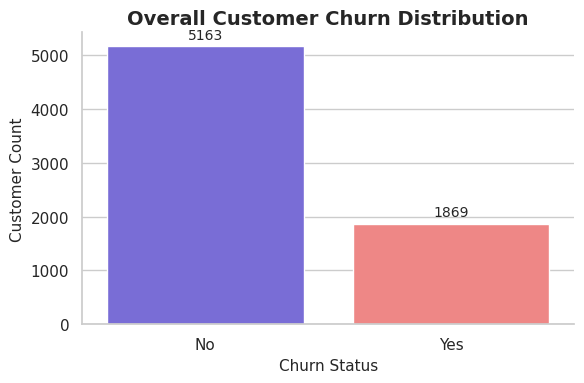

In [349]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    x="Churn",
    data=df,
    hue="Churn",
    palette=["#6C5CE7", "#FF7675"],
    legend=False
)

plt.title("Overall Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

sns.despine()
plt.tight_layout()
plt.show()

#### Key Insight

The customer base is primarily composed of retained customers, although a substantial proportion of customers have churned. This indicates that customer attrition represents a meaningful business concern requiring targeted retention strategies.

## Contract Type vs Churn

### Business Question

How does contract duration influence customer churn behavior?
### Why This Matters

Contract duration reflects customer commitment and retention stability. Understanding churn behavior across contract categories helps identify vulnerable customer groups.**bold text**

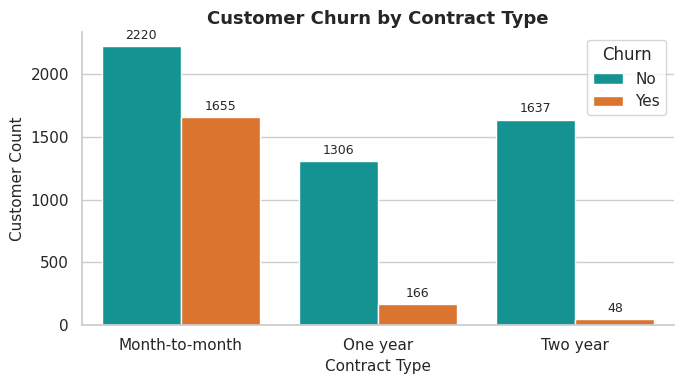

In [350]:
plt.figure(figsize=(7, 4))

ax = sns.countplot(
    x="Contract",
    hue="Churn",
    data=df,
    palette=["#00A8A8", "#F76E11"]
)

plt.title("Customer Churn by Contract Type", fontsize=13, weight='bold')
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.legend(title="Churn", frameon=True, loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=3)

sns.despine()
plt.tight_layout()
plt.show()

#### Key Insight

Month-to-month customers demonstrate substantially higher churn volumes compared to customers with one-year and two-year contracts. This reinforces contract duration as one of the strongest customer retention indicators within the analysis.

## Payment Method vs Churn
### Business Question

Does customer payment behavior influence churn tendencies?
### Why This Matters

Payment behavior may reflect customer commitment patterns, convenience preferences, and billing experience, all of which can influence customer retention outcomes.**bold text**

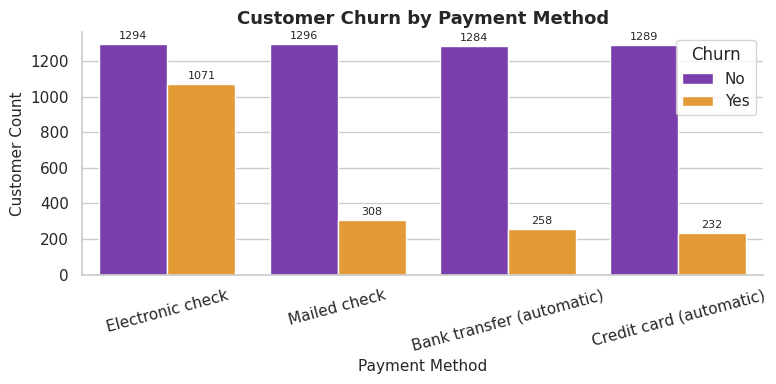

In [351]:
plt.figure(figsize=(8,4))

ax = sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df,
    palette=["#7B2CBF", "#FF9F1C"]
)

plt.title("Customer Churn by Payment Method", fontsize=13, weight='bold')
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")

plt.xticks(rotation=15)

plt.legend(title="Churn", frameon=True, loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)

sns.despine()
plt.tight_layout()
plt.show()

#### Key Insight

Customers using electronic check payment methods demonstrate noticeably higher churn volumes compared to customers using automatic payment methods, indicating that payment behavior may serve as an important churn risk indicator.

## Internet Service vs Churn
### Business Question

How does internet service type influence customer churn behavior?
### Why This Matters

Internet service quality and pricing expectations can strongly influence customer satisfaction and long-term retention behavior.

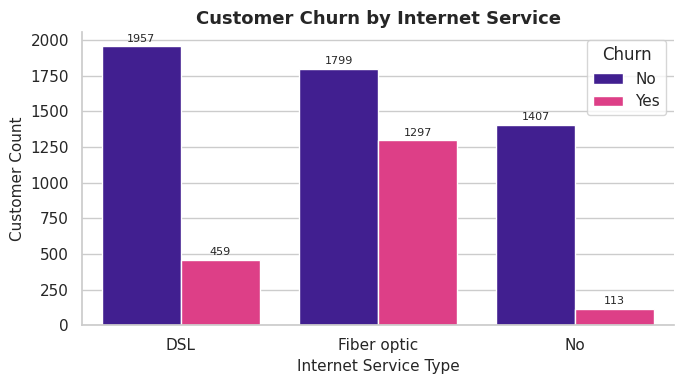

In [352]:
plt.figure(figsize=(7,4))

ax = sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df,
    palette=["#3A0CA3", "#F72585"]
)

plt.title("Customer Churn by Internet Service", fontsize=13, weight='bold')
plt.xlabel("Internet Service Type")
plt.ylabel("Customer Count")

plt.legend(title="Churn", frameon=True, loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fontsize=8, padding=2)

sns.despine()
plt.tight_layout()
plt.show()

#### Key Insight

Customers using fiber optic internet services exhibit substantially higher churn volumes compared to DSL users and customers without internet services, suggesting elevated churn risk among higher-service-tier customers.

## Monthly Charges vs Churn
### Business Question

Do customers with higher monthly charges exhibit greater churn behavior?
### Why This Matters

Pricing sensitivity and perceived service value can significantly influence customer retention decisions and churn behavior.

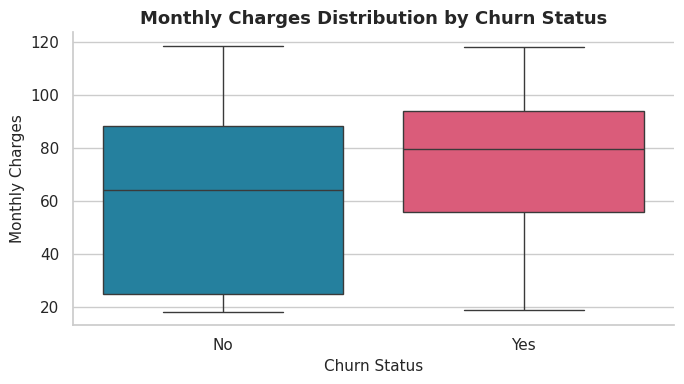

In [353]:
plt.figure(figsize=(7,4))

ax = sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    data=df,
    palette=["#118AB2", "#EF476F"],
    legend=False
)

plt.title("Monthly Charges Distribution by Churn Status", fontsize=13, weight='bold')
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

sns.despine()
plt.tight_layout()
plt.show()

#### Key Insight

Customers who churn generally exhibit higher monthly charge distributions compared to retained customers, suggesting that elevated pricing may contribute to increased churn risk.

## Internet Service vs Monthly Charges
### Business Question

How do pricing distributions differ across internet service categories?
### Why This Matters

Different internet service categories represent distinct pricing tiers and customer value segments, which may influence customer expectations and retention behavior.

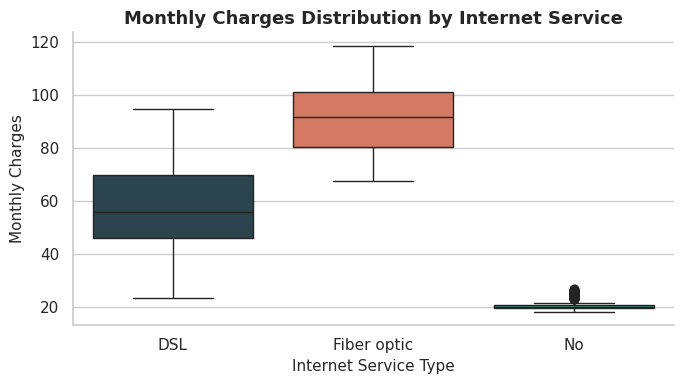

In [354]:
plt.figure(figsize=(7,4))

ax = sns.boxplot(
    x="InternetService",
    y="MonthlyCharges",
    hue="InternetService",
    data=df,
    palette=["#264653", "#E76F51", "#2A9D8F"],
    legend=False
)

plt.title("Monthly Charges Distribution by Internet Service", fontsize=13, weight='bold')
plt.xlabel("Internet Service Type")
plt.ylabel("Monthly Charges")

sns.despine()
plt.tight_layout()
plt.show()

#### Key Insight

Fiber optic customers exhibit the highest monthly charge distributions among all internet service categories, reflecting premium pricing structures associated with higher-tier internet services.

## Tenure vs Churn
### Business Question

Do customers with shorter tenure exhibit higher churn behavior?
### Why This Matters

Customer tenure reflects relationship maturity and retention stability. Understanding tenure differences between churned and retained customers helps identify vulnerable lifecycle stages.

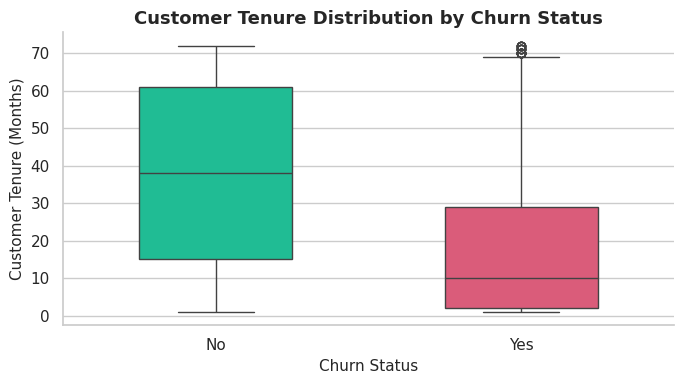

In [355]:
plt.figure(figsize=(7,4))

ax = sns.boxplot(
    x="Churn",
    y="tenure",
    hue="Churn",
    data=df,
    palette=["#06D6A0", "#EF476F"],
    legend=False,
    width=0.5
)

plt.title("Customer Tenure Distribution by Churn Status", fontsize=13, weight='bold')
plt.xlabel("Churn Status")
plt.ylabel("Customer Tenure (Months)")

sns.despine()
plt.tight_layout()
plt.show()

#### Key Insight

Customers who churn generally exhibit substantially lower tenure distributions compared to retained customers, indicating that newer customers face significantly higher churn vulnerability.

## Correlation Analysis
Correlation analysis was conducted to evaluate numerical relationships between key customer variables associated with churn behavior and customer lifecycle characteristics.

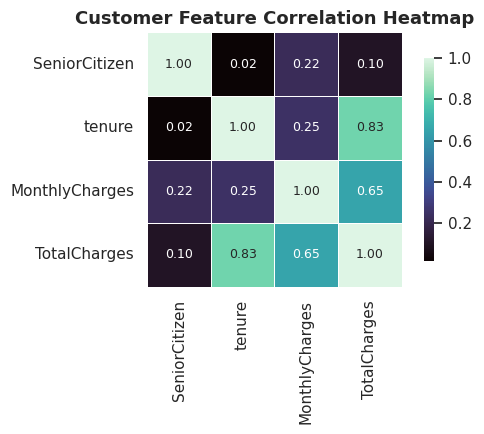

In [356]:
plt.figure(figsize=(6,4.5))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="mako",
    linewidths=0.5,
    square=True,
    annot_kws={"size":9},
    cbar_kws={"shrink": 0.8}
)

plt.title("Customer Feature Correlation Heatmap", fontsize=13, weight='bold')

plt.tight_layout()
plt.show()

#### Key Insight

Tenure and TotalCharges exhibit a strong positive correlation, indicating that longer-tenured customers generally accumulate higher overall revenue contributions. MonthlyCharges also demonstrates a moderate positive relationship with TotalCharges.

## High-Risk Customer Segment Analysis

This section identifies customer groups with significantly elevated churn vulnerability by combining the strongest churn indicators discovered during the analytical and statistical validation stages.

The overall customer churn rate across the dataset is approximately 26.5%. The following segment analysis highlights customer groups whose churn behavior substantially exceeds the overall churn baseline.

### Segment 1: Month-to-Month Fiber Optic Customers

#### Business Question

Do customers with month-to-month contracts and fiber optic internet show elevated churn risk?

In [357]:
segment_1 = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic')
]

(segment_1['Churn'].value_counts(normalize=True) * 100).round(1)

,proportion
Churn,
Yes,54.6
No,45.4


#### Key Insight

Month-to-month customers using fiber optic internet services exhibit extremely elevated churn vulnerability, with churn reaching approximately 54.6% — more than double the overall customer churn rate. This segment represents one of the most critical customer retention risk groups identified during the analysis.

### Segment 2: High-Charge Month-to-Month Customers

#### Business Question

Do customers with high monthly charges and flexible contract structures demonstrate increased churn vulnerability?

In [358]:
segment_2 = df[
    (df['MonthlyCharges'] > 80) &
    (df['Contract'] == 'Month-to-month')
]

(segment_2['Churn'].value_counts(normalize=True) * 100).round(1)

,proportion
Churn,
Yes,52.2
No,47.8


#### Key Insight

Customers with high monthly charges under flexible contract structures exhibit churn rates exceeding 52%, nearly double the overall customer churn baseline. This suggests that premium-priced customers without long-term contractual commitment represent a particularly unstable customer segment.

### Segment 3: Senior Citizens Using Fiber Optic Internet

#### Business Question

Do senior citizen customers using fiber optic internet services exhibit elevated churn vulnerability?

In [359]:
segment_3 = df[
    (df['SeniorCitizen'] == 1) &
    (df['InternetService'] == 'Fiber optic')
]

(segment_3['Churn'].value_counts(normalize=True) * 100).round(1)

,proportion
Churn,
No,52.7
Yes,47.3


#### Key Insight

Senior citizen customers using fiber optic internet services exhibit churn rates of approximately 47.3%, substantially exceeding the overall customer churn baseline. This suggests that senior customers within higher-service-tier offerings may require additional customer support, pricing clarity, or service engagement initiatives to improve retention.

### Segment 4: Low-Tenure High-Charge Customers

#### Business Question

Do newly acquired customers with high monthly charges exhibit elevated churn vulnerability?

In [360]:
segment_4 = df[
    (df['tenure'] <= 12) &
    (df['MonthlyCharges'] > 80)
]

(segment_4['Churn'].value_counts(normalize=True) * 100).round(1)

,proportion
Churn,
Yes,72.7
No,27.3


#### Key Insight

Newly acquired customers with high monthly charges exhibit extremely severe churn behavior, with churn reaching approximately 72.7% — nearly three times the overall customer churn baseline. This suggests that high-cost service adoption during the early customer lifecycle may create substantial retention instability.

### Segment 5: Premium Fiber Optic Customers

#### Business Question

Do customers using premium fiber optic internet services with high monthly charges exhibit elevated churn vulnerability?

In [361]:
segment_5 = df[
    (df['InternetService'] == 'Fiber optic') &
    (df['MonthlyCharges'] > 80)
]

(segment_5['Churn'].value_counts(normalize=True) * 100).round(1)

,proportion
Churn,
No,62.4
Yes,37.6


#### Key Insight

Customers using premium fiber optic internet services with high monthly charges exhibit elevated churn behavior, with churn reaching approximately 37.6% — notably above the overall churn baseline of 26.5%. However, compared to other high-risk segments, this indicates that premium pricing alone may not be the strongest churn driver unless combined with additional retention risk factors such as short tenure or flexible contracts.

## Business Simulation & Retention Impact Analysis
This section evaluates the potential business impact of customer churn within the highest-risk customer segment identified during the analysis.

A hypothetical retention intervention scenario was simulated to estimate potential customer retention improvement and monthly revenue preservation.

In [362]:
high_risk_customers = segment_4.shape[0]

segment_churn_rate = 0.727

estimated_churn_customers = (
    high_risk_customers * segment_churn_rate
)

print("Simulation Summary")
print("-" * 30)

print(f"High-Risk Customers      : {high_risk_customers}")
print(f"Estimated Churn Customers : {estimated_churn_customers:.0f}")

Simulation Summary
------------------------------
High-Risk Customers      : 472
Estimated Churn Customers : 343


### Retention Intervention Scenario

A hypothetical 15% churn reduction scenario was simulated to estimate customer retention impact.

In [363]:
target_churn_reduction = 0.15

retained_customers = (
    estimated_churn_customers * target_churn_reduction
)

print(f"Potential Customers Retained : {retained_customers:.0f}")

Potential Customers Retained : 51


### Average Revenue Contribution

In [364]:
average_monthly_revenue = (
    segment_4['MonthlyCharges'].mean()
)

print(
    f"Average Monthly Revenue per Customer : "
    f"{average_monthly_revenue:.2f} monetary units"
)

Average Monthly Revenue per Customer : 90.14 monetary units


### Estimated Revenue Preservation

In [365]:
potential_revenue_saved = (
    retained_customers * average_monthly_revenue
)

print(
    f"Estimated Monthly Revenue Preservation : "
    f"{potential_revenue_saved:.0f} monetary units"
)

Estimated Monthly Revenue Preservation : 4640 monetary units


### Business Impact Insight

The highest-risk customer segment demonstrates a churn rate of approximately 72.7%, significantly exceeding the overall churn baseline.

A simulated 15% reduction in churn within this segment could potentially retain nearly 51 customers and preserve approximately 4,640 monetary units in monthly revenue.

These findings highlight the substantial financial impact of targeted retention strategies focused on high-risk customer groups.

## Comparative Segment Risk Summary
The following summary compares churn exposure across the identified high-risk customer segments to support business prioritization.

In [366]:
risk_summary = pd.DataFrame({
    'Segment': [
    'Month-to-Month Fiber Optic',
    'High-Charge Month-to-Month Customers',
    'Senior Citizens Using Fiber Optic',
    'Low-Tenure High-Charge Customers',
    'Premium Fiber Optic Customers'
  ],

    'Churn Rate (%)': [
        54.6,
        52.2,
        47.3,
        72.7,
        37.6
    ]
})

risk_summary.sort_values(
    by='Churn Rate (%)',
    ascending=False
)

,Segment,Churn Rate (%)
3,Low-Tenure High-Charge Customers,72.7
0,Month-to-Month Fiber Optic,54.6
1,High-Charge Month-to-Month Customers,52.2
2,Senior Citizens Using Fiber Optic,47.3
4,Premium Fiber Optic Customers,37.6


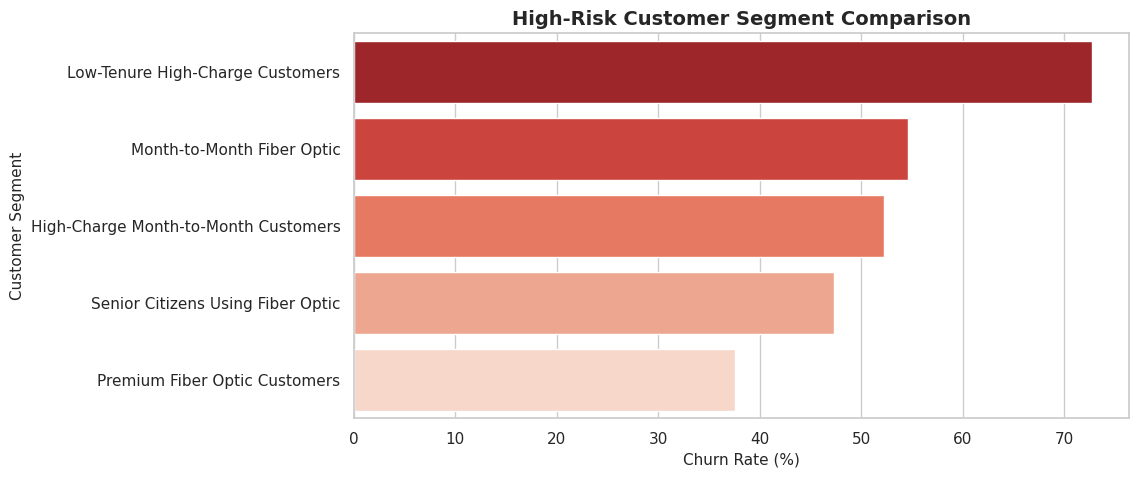

In [367]:
plt.figure(figsize=(10,5))

sorted_summary = risk_summary.sort_values(
    by='Churn Rate (%)',
    ascending=False
)

sns.barplot(
    data=sorted_summary,
    x='Churn Rate (%)',
    y='Segment',
    hue='Segment',
    palette='Reds_r',
    legend=False
)

plt.title(
    'High-Risk Customer Segment Comparison',
    fontsize=14
)

plt.xlabel('Churn Rate (%)')
plt.ylabel('Customer Segment')

plt.show()

### Executive Insight

Low-tenure customers with high monthly charges represent the most critical churn-risk segment, exhibiting the highest churn exposure across all identified customer groups.

Customers operating under flexible month-to-month contracts, particularly those using fiber optic services or paying premium monthly charges, also demonstrate significantly elevated churn vulnerability.

These findings indicate that early customer lifecycle instability, pricing pressure, and low contractual commitment are major drivers of customer attrition.

Targeted retention initiatives focused on onboarding stabilization, pricing optimization, and long-term contract incentives may substantially improve customer retention performance.

## KPI Dashboard & Executive Metrics

This section summarizes the most important business metrics derived from the churn analysis.

The dashboard presents an executive-level view of customer base overview, churn performance, high-risk segment priority, and simulated retention impact.


### Executive KPI Summary Table

The following table consolidates the key business metrics derived from the churn analysis, high-risk customer segmentation, and retention impact simulation.

In [368]:
# Core customer base metrics
total_customers = len(df)

overall_churn_rate = (df['Churn'] == 'Yes').mean() * 100
overall_retention_rate = (df['Churn'] == 'No').mean() * 100
churned_customers = (df['Churn'] == 'Yes').sum()

# Highest-risk segment metrics
highest_risk_segment = "Low-Tenure High-Charge Customers"
highest_risk_segment_size = segment_4.shape[0]
highest_risk_segment_churn = 72.7

# Retention impact simulation metrics
target_churn_reduction = 0.15

segment_churn_rate = (
    segment_4['Churn']
    .value_counts(normalize=True)['Yes']
)

estimated_churn_customers = highest_risk_segment_size * segment_churn_rate
potential_customers_retained = estimated_churn_customers * target_churn_reduction

average_segment_monthly_revenue = segment_4['MonthlyCharges'].mean()
estimated_monthly_revenue_preserved = (
    potential_customers_retained * average_segment_monthly_revenue
)

kpi_dashboard = pd.DataFrame({
    "Business Area": [
        "Customer Base Overview",
        "Customer Base Overview",
        "Churn Performance",
        "Churn Performance",
        "High-Risk Segment Priority",
        "High-Risk Segment Priority",
        "High-Risk Segment Priority",
        "Retention Impact Simulation",
        "Retention Impact Simulation"
    ],

    "Metric": [
        "Total Customers",
        "Overall Retention Rate",
        "Overall Churn Rate",
        "Churned Customers",
        "Highest-Risk Segment",
        "Highest-Risk Segment Size",
        "Highest-Risk Segment Churn Rate",
        "Potential Customers Retained Under 15% Churn Reduction",
        "Estimated Monthly Revenue Preserved"
    ],

    "Value": [
        f"{total_customers:,}",
        f"{overall_retention_rate:.1f}%",
        f"{overall_churn_rate:.1f}%",
        f"{churned_customers:,}",
        highest_risk_segment,
        f"{highest_risk_segment_size:,}",
        f"{highest_risk_segment_churn:.1f}%",
        f"{potential_customers_retained:.0f}",
        f"{estimated_monthly_revenue_preserved:,.0f} monetary units"
    ],

    "Basis / Interpretation": [
        "Total customer records analyzed",
        "Customers retained within the dataset",
        "Overall customer attrition level",
        "Total customers marked as churned",
        "Segment with the highest observed churn rate",
        "Customers belonging to the highest-risk segment",
        "Observed churn rate within the highest-risk segment",
        "Based on a simulated 15% churn reduction in the highest-risk segment",
        "Based on retained customers × average monthly charges of the highest-risk segment"
    ]
})

kpi_dashboard

,Business Area,Metric,Value,Basis / Interpretation
0,Customer Base Overview,Total Customers,"7,032",Total customer records analyzed
1,Customer Base Overview,Overall Retention Rate,73.4%,Customers retained within the dataset
2,Churn Performance,Overall Churn Rate,26.6%,Overall customer attrition level
3,Churn Performance,Churned Customers,"1,869",Total customers marked as churned
4,High-Risk Segment Priority,Highest-Risk Segment,Low-Tenure High-Charge Customers,Segment with the highest observed churn rate
5,High-Risk Segment Priority,Highest-Risk Segment Size,472,Customers belonging to the highest-risk segment
6,High-Risk Segment Priority,Highest-Risk Segment Churn Rate,72.7%,Observed churn rate within the highest-risk se...
7,Retention Impact Simulation,Potential Customers Retained Under 15% Churn R...,51,Based on a simulated 15% churn reduction in th...
8,Retention Impact Simulation,Estimated Monthly Revenue Preserved,"4,638 monetary units",Based on retained customers × average monthly ...


### KPI Visual Dashboard

The following KPI cards highlight the most important executive metrics from the churn analysis and retention impact simulation.

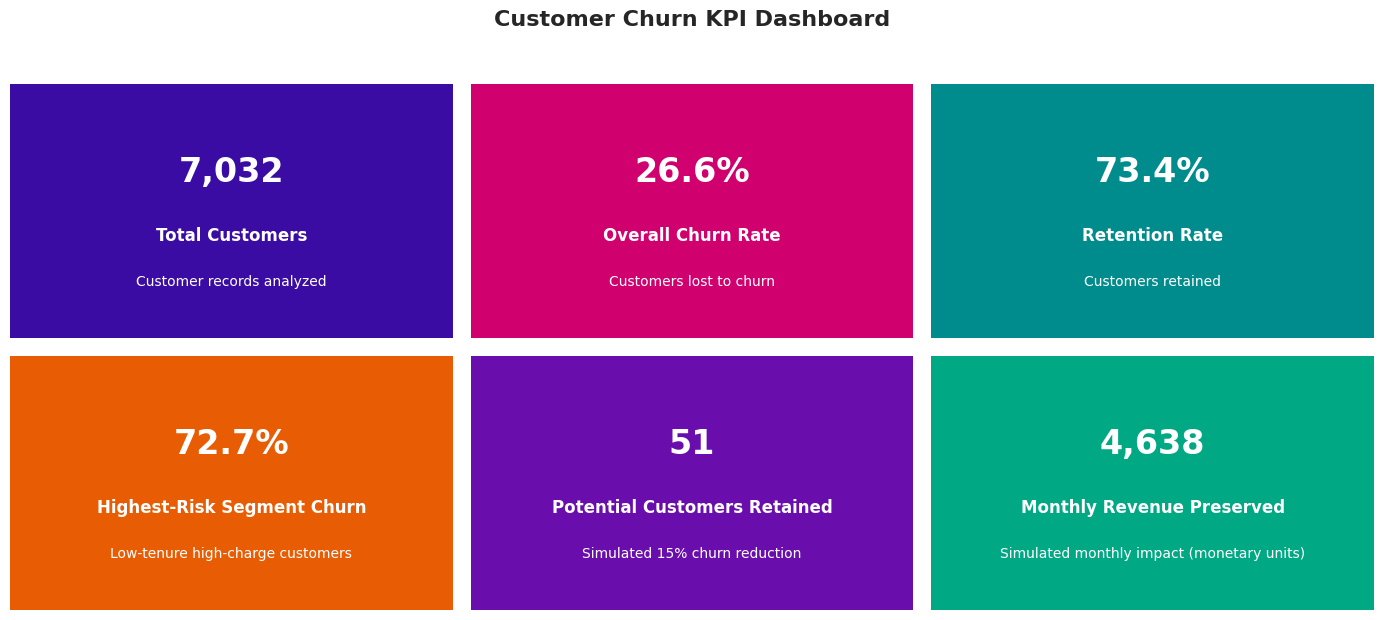

In [369]:
# KPI card values

currency_label = "monetary units"

kpi_cards = [
    {
        "title": "Total Customers",
        "value": f"{total_customers:,}",
        "subtitle": "Customer records analyzed"
    },
    {
        "title": "Overall Churn Rate",
        "value": f"{overall_churn_rate:.1f}%",
        "subtitle": "Customers lost to churn"
    },
    {
        "title": "Retention Rate",
        "value": f"{overall_retention_rate:.1f}%",
        "subtitle": "Customers retained"
    },
    {
        "title": "Highest-Risk Segment Churn",
        "value": f"{highest_risk_segment_churn:.1f}%",
        "subtitle": "Low-tenure high-charge customers"
    },
    {
        "title": "Potential Customers Retained",
        "value": f"{potential_customers_retained:.0f}",
        "subtitle": "Simulated 15% churn reduction"
    },
    {
        "title": "Monthly Revenue Preserved",
        "value": f"{estimated_monthly_revenue_preserved:,.0f}",
        "subtitle": f"Simulated monthly impact ({currency_label})"
    }
]

# Premium dashboard colors
card_colors = [
    "#3A0CA3",  # Total Customers
    "#D0006F",  # Churn Rate
    "#008C8C",  # Retention Rate
    "#E85D04",  # Highest-Risk Segment Churn
    "#6A0DAD",  # Customers Retained
    "#00A884"   # Revenue Preserved
]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.set_facecolor(card_colors[i])

    ax.text(
        0.5, 0.65,
        kpi_cards[i]["value"],
        ha="center",
        va="center",
        fontsize=24,
        fontweight="bold",
        color="white"
    )

    ax.text(
        0.5, 0.40,
        kpi_cards[i]["title"],
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white"
    )

    ax.text(
        0.5, 0.22,
        kpi_cards[i]["subtitle"],
        ha="center",
        va="center",
        fontsize=10,
        color="white"
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle(
    "Customer Churn KPI Dashboard",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

### Dashboard Takeaway

The KPI dashboard shows that overall churn affects approximately one-fourth of the customer base, while churn risk is highly concentrated within specific high-risk customer groups.

Low-tenure high-charge customers represent the most critical retention priority, with churn reaching approximately 72.7%. Under a simulated 15% churn reduction scenario, this segment could retain around 51 customers and preserve approximately 4,638 monetary units in monthly revenue.

This reinforces the importance of targeted retention strategies for early-stage, high-value customers.

## Retention Strategy Roadmap
This roadmap converts the churn analysis into prioritized business actions. Recommendations are ordered by churn severity, high-risk segment concentration, and retention impact potential.

| Priority | Strategic Focus | Target Segment | Recommended Action |
|---|---|---|---|
| P1 | Stabilize Early-Stage High-Charge Customers | Low-tenure high-charge customers | Strengthen onboarding, proactive check-ins, and early retention offers |
| P2 | Convert Flexible Contracts into Long-Term Plans | Month-to-month customers | Offer upgrade incentives, loyalty benefits, and bundled long-term plans |
| P3 | Optimize Pricing for High-Charge Customers | High monthly charge customers | Introduce targeted discounts, value bundles, and personalized pricing support |
| P4 | Improve Fiber Optic Customer Experience | Fiber optic and premium-service customers | Strengthen technical support, service monitoring, and premium retention packages |
| P5 | Build Segment-Based Retention Campaigns | Customers with multiple churn-risk signals | Create targeted campaigns and track retention outcomes by segment |
| P6 | Promote Automatic Payment Adoption | Electronic check payment users | Simplify auto-pay enrollment and encourage automatic payment methods |
| P7 | Strengthen Senior Customer Support | Senior customers using premium services | Provide clearer communication, proactive support, and simplified billing assistance |

### Strategic Takeaway

The strongest retention opportunity lies in targeting customers who combine multiple churn-risk signals, especially low tenure, high monthly charges, flexible contracts, and premium service usage.

A segment-based retention strategy is likely to be more effective than broad retention campaigns because churn risk is concentrated within clearly identifiable customer groups.

## Final Conclusion

This project analyzed customer churn behavior to identify key factors associated with customer attrition and translate those findings into actionable business recommendations.

The analysis showed that churn risk is meaningfully associated with contract type, tenure, monthly charges, internet service type, payment method, and senior citizen status. Statistical validation further supported that these churn patterns were unlikely to be driven by random variation alone.

High-risk segmentation revealed that churn is not evenly distributed across the customer base. The most critical segment was low-tenure customers with high monthly charges, showing a churn rate of approximately 72.7%, far above the overall churn baseline.

The retention impact simulation showed that a targeted 15% churn reduction within this segment could potentially retain around 51 customers and preserve approximately 4,638 monetary units in monthly revenue.

Overall, the findings suggest that retention efforts should prioritize early-stage high-charge customers, flexible contract users, fiber optic customers, and customers showing multiple churn-risk signals.

A focused, segment-based retention strategy can help reduce avoidable churn, improve customer stability, and protect recurring revenue.